# Spotify Data Analysis




---
## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

print('All imports successful')

All imports successful


## 2. Analysis Pipeline


In [3]:
class SpotifyAnalyser:
    def __init__(self, filepath):
        """
        Initialises the SpotifyAnalyser with all attributes needed
        
        across the four research question pipelines.
        """
        # --- Data Storage ---
        self.filepath = filepath
        self.dataset = None
        self.cleaned_dataset = None

        # Audio features used in all analyses
        self.feature_cols = [
            'acousticness', 'danceability', 'energy', 'instrumentalness',
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
        ]

       
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        
        self.scaler = None
        self.knn_model = None
        self.predictions = None
        
        self.evaluation_metrics = {}
        self.confusion_matrices = {}
        

       
        self.pca_scaler   = None
        self.pca_model    = None
        self.X_2d         = None
        self.loadings     = None
        self.n_components = None

       
        self.corr_matrix = None

    
    # SECTION A: Data Loading and Preprocessing
    
    def load_data(self):
        """
        Loads the dataset from the CSV file path provided at initialisation.
        """
        self.dataset = pd.read_csv(self.filepath)
        # Remove the auto-generated index column Kaggle adds
        self.dataset = self.dataset.drop(columns=['Unnamed: 0'], errors='ignore')
        print(f'Data successfully loaded: {self.dataset.shape[0]} rows x {self.dataset.shape[1]} columns')

    def clean_data(self):
        
        df = self.dataset.copy()

        # Remove duplicate rows
        initial_count = len(df)
        df = df.drop_duplicates()
        print(f'Removed {initial_count - len(df)} duplicate rows.')

        # Handle missing values in feature and target columns
        missing = df[self.feature_cols + ['target']].isnull().sum().sum()
        if missing > 0:
            df = df.dropna(subset=self.feature_cols + ['target'])
            print(f'Removed rows with missing values. Remaining: {len(df)}')
        else:
            print('No missing values found in feature or target columns. \u2713')

        # Validate numeric data types for feature columns
        for col in self.feature_cols:
            if not pd.api.types.is_numeric_dtype(df[col]):
                print(f'  Warning: column "{col}" is not numeric and will be excluded.')
                self.feature_cols.remove(col)

        # Report class balance
        counts = df['target'].value_counts()
        print(f'\nTarget distribution:')
        print(f'  Liked    (1): {counts[1]} tracks ({counts[1]/len(df)*100:.1f}%)')
        print(f'  Disliked (0): {counts[0]} tracks ({counts[0]/len(df)*100:.1f}%)')

        self.cleaned_dataset = df
        print('\nData cleaning complete.')

    
    # SECTION B: RQ1 — Taste Prediction via k-NN Classification

    def prepare_features(self, split_ratio=0.8):
        """
        Scales the audio features using StandardScaler and splits the data
        into training and testing sets.

        """
        X = self.cleaned_dataset[self.feature_cols]
        y = self.cleaned_dataset['target']

        # Standardise
        self.scaler = StandardScaler()
        X_scaled    = self.scaler.fit_transform(X)

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X_scaled, y, train_size=split_ratio, random_state=42
        )
        print(f'Features scaled | Train: {self.X_train.shape[0]} samples | Test: {self.X_test.shape[0]} samples')

    def train_model(self, k=5):
         #Trains the k-NN classifier on the training data
        self.knn_model = KNeighborsClassifier(n_neighbors=k)
        
        
        self.knn_model.fit(self.X_train, self.y_train)
        print(f'k-NN model trained successfully')

    def test_model(self):
        
        #Generates predictions on the test set using the trained k-NN model.
        
        self.predictions = self.knn_model.predict(self.X_test)
        print('Predictions generated for test set.')
        return self.predictions

    def store_metrics(self, predictions, scenario_name):
        
        #Calculates and stores evaluation metrics and the confusion matrix
        
        self.evaluation_etrics[scenario_name] = {
            'Accuracy' : accuracy_score(self.y_test, predictions),
            'Precision': precision_score(self.y_test, predictions, zero_division=0),
            'Recall'   : recall_score(self.y_test, predictions, zero_division=0),
            'F1-Score' : f1_score(self.y_test, predictions, zero_division=0)
        }
        self.confusion_matrices[scenario_name] = confusion_matrix(self.y_test, predictions)

    def visualise_confusion_matrix(self, predictions):
        
        #Plots a Seaborn heatmap of the confusion matrix.
        
        cm = confusion_matrix(self.y_test, predictions)

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Disliked', 'Liked'],
            yticklabels=['Disliked', 'Liked']
        )
        plt.title('Confusion Matrix: k-NN Song Taste Prediction (k=5)')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.show()

    
    # SECTION C: RQ2 — Do Liked Songs Sound Different?

    def compare_feature_groups(self):
        """
        Computes and prints the mean value of each audio feature
        for liked and disliked songs, and calculates the Pearson
        correlation of each feature with the target label.
        
        """
        df  = self.cleaned_dataset
        avg = df.groupby('target')[self.feature_cols].mean()

        print('Average Feature Values by Group')
        print(avg.round(3))

        corr = (df[self.feature_cols + ['target']]
                .corr()['target']
                .drop('target')
                .sort_values(ascending=False))

        print(' Pearson Correlation with Target (Liked = 1)')
        print(corr.round(4))

        return avg, corr

    def visualise_feature_boxplots(self):
        """
        Plots a 2x3 grid of side-by-side box plots for the six most
        perceptually meaningful features, split by liked vs disliked.
        
        """
        df    = self.cleaned_dataset
        liked = df[df['target'] == 1]
        dis   = df[df['target'] == 0]

        key_features = ['danceability', 'energy', 'valence',
                        'acousticness', 'loudness', 'tempo']

        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        axes = axes.flatten()

        for i, feat in enumerate(key_features):
            bp = axes[i].boxplot(
                [dis[feat], liked[feat]],
                labels=['Disliked', 'Liked'],
                patch_artist=True
                
            )
            bp['boxes'][0].set_facecolor('#E07070')
            bp['boxes'][1].set_facecolor('#70B0E0')
            axes[i].set_title(feat.capitalize(), fontweight='bold')
            axes[i].set_ylabel(feat)
            axes[i].grid(True, linestyle='--', alpha=0.5)

        plt.suptitle('Do Liked Songs Actually Sound Different? Feature-by-Feature Comparison',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()
        
    def visualise_correlation_bar(self):
        
        df   = self.cleaned_dataset
        corr = (df[self.feature_cols + ['target']]
                .corr()['target']
                .drop('target')
                .sort_values())

        colours = ['#70B0E0' if v > 0 else '#E07070' for v in corr]

        plt.figure(figsize=(10, 5))
        plt.barh(corr.index, corr.values, color=colours)
        plt.title('Correlation of Audio Features with Liked Songs')
        plt.xlabel('Correlation with Liked (target = 1)')
        
        plt.tight_layout()
        plt.show()

    # SECTION D: RQ3 — How many sound dimensions does Spotify actually need to describe a song?
    
    def apply_pca(self, target_variance=0.80):
        
        """
        Applies PCA to find the minimum number of audio dimensions
        needed to capture target_variance of the data's variation.
        
        """
        df = self.cleaned_dataset

        # Scale the features (PCA is sensitive to scale)
        self.pca_scaler = StandardScaler()
        X_scaled        = self.pca_scaler.fit_transform(df[self.feature_cols])

        # Exploratory PCA: how many components reach the target variance?
        pca_explore        = PCA(n_components=len(self.feature_cols), random_state=42)
        pca_explore.fit(X_scaled)
        cumulative_variance = np.cumsum(pca_explore.explained_variance_ratio_)

        self.n_components = int(np.argmax(cumulative_variance >= target_variance)) + 1

        # Plot cumulative variance curve
        plt.figure(figsize=(9, 5))
        plt.plot(
            range(1, len(self.feature_cols) + 1), cumulative_variance,
            marker='o', color='seagreen', linewidth=2,
            label='Cumulative Explained Variance'
        )
        plt.axhline(y=target_variance, color='red', linewidth=1.5,
                    label=f'{int(target_variance*100)}% Variance Threshold')
        plt.axvline(x=self.n_components, color='orange', linewidth=1.5,
                    label=f'{self.n_components} components needed')
        plt.title('Cumulative Explained Variance by Number of PCA Components')
        
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Explained Variance')
        plt.xticks(range(1, len(self.feature_cols) + 1))
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        print(f'Components needed to capture {int(target_variance*100)}% of variance: {self.n_components}')
        print(f'This means {self.n_components} out of 9 features capture most of what makes songs sound different.')
        
    
    # SECTION E: RQ4 — Can we identify distinct song types and does the listener consistently prefer one?

    def cluster_songs(self, n_clusters=4):
    
        """
        Groups songs into n_clusters using K-Means clustering
        on the normalised audio features. Then calculates the
        like rate per cluster to see if one sound profile is
        consistently preferred.

        """

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.cleaned_dataset[self.feature_cols])
        
        # Fit K-Means
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        self.cleaned_dataset['Cluster'] = kmeans.fit_predict(X_scaled)

        # Evaluate cluster 
        sil_score = silhouette_score(X_scaled, self.cleaned_dataset['Cluster'])
        print(f'Silhouette Score (k={n_clusters}): {sil_score:.4f}')
        print('(Score closer to 1.0 means clusters are well separated)')

        # Like rate per cluster
        like_rate = (self.cleaned_dataset
                     .groupby('Cluster')['target']
                     .mean()
                     .round(3)
                     .reset_index())
        like_rate.columns = ['Cluster', 'Like Rate']

        print('Like Rate per Cluster')
        print(like_rate.to_string(index=False))

        # Bar chart of like rate per cluster
        plt.figure(figsize=(8, 5))
        plt.bar(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'], like_rate['Like Rate'], color=['#70B0E0', '#E07070', '#90C990', '#F0C060'])
        plt.axhline(0.5, color='red', linestyle='--', label='50% baseline')

        for i, rate in enumerate(like_rate['Like Rate']):
            plt.text(i, rate + 0.01, str(rate), ha='center')

        plt.title('Like Rate per Cluster')
        plt.xlabel('Cluster')
        plt.ylabel('Like Rate')
        plt.ylim(0, 0.7)
        plt.legend()
        plt.show()



print('SpotifyAnalyser class defined successfully')

SpotifyAnalyser class defined successfully


---
## 3. Data Loading and Preprocessing

In [4]:
spotify = SpotifyAnalyser('data.csv')
spotify.load_data()
spotify.clean_data()

Data successfully loaded: 2017 rows x 16 columns
Removed 5 duplicate rows.
No missing values found in feature or target columns. ✓

Target distribution:
  Liked    (1): 1015 tracks (50.4%)
  Disliked (0): 997 tracks (49.6%)

Data cleaning complete.


In [5]:
# Preview the cleaned dataset
spotify.cleaned_dataset.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino
2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future
3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House
4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys


In [6]:
# Summary statistics for all audio features
spotify.cleaned_dataset[spotify.feature_cols].describe().round(3)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,2012.000,2012.000,2012.000,2012.000,2012.000,2012.000,2012.000,2012.000,2012.000
mean,0.188,0.618,0.682,0.133,0.191,-7.077,0.093,121.602,0.497
std,0.260,0.161,0.210,0.273,0.156,3.757,0.090,26.688,0.247
min,0.000,0.122,0.015,0.000,0.019,-33.097,0.023,47.859,0.035
25%,0.010,0.514,0.564,0.000,0.092,-8.392,0.038,100.164,0.296
50%,0.064,0.631,0.716,0.000,0.126,-6.248,0.055,121.407,0.493
75%,0.265,0.738,0.846,0.054,0.246,-4.744,0.108,137.695,0.692
max,0.995,0.984,0.998,0.976,0.969,-0.307,0.816,219.331,0.992


## RQ1 — *Can we predict if a song will be liked?*


Features scaled | Train: 1609 samples | Test: 403 samples
k-NN model trained successfully
Predictions generated for test set.


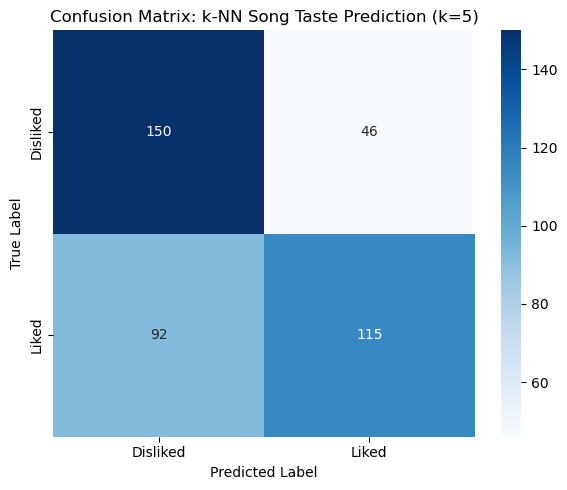

In [6]:
# Prepare features and split into 80% training / 20% testing
spotify.prepare_features(split_ratio=0.8)
spotify.train_model(k=5)
predictions = spotify.test_model()
spotify.visualise_confusion_matrix(predictions)

---
## RQ2 — *Do liked and disliked songs actually sound different?*

We compare the distribution of each audio feature between the two groups 
using box plots (to see the spread and median) and a correlation bar chart 
(to quantify the direction and strength of each feature's relationship with 
being liked).

In [7]:
avg_by_group, correlations = spotify.compare_feature_groups()

Average Feature Values by Group
        acousticness  danceability  energy  instrumentalness  liveness  \
target                                                                   
0              0.222         0.590   0.673             0.091     0.187   
1              0.154         0.647   0.690             0.174     0.195   

        loudness  speechiness    tempo  valence  
target                                           
0         -6.812        0.079  120.666    0.470  
1         -7.337        0.106  122.522    0.524  
 Pearson Correlation with Target (Liked = 1)
danceability        0.1773
speechiness         0.1539
instrumentalness    0.1520
valence             0.1101
energy              0.0410
tempo               0.0348
liveness            0.0262
loudness           -0.0699
acousticness       -0.1304
Name: target, dtype: float64


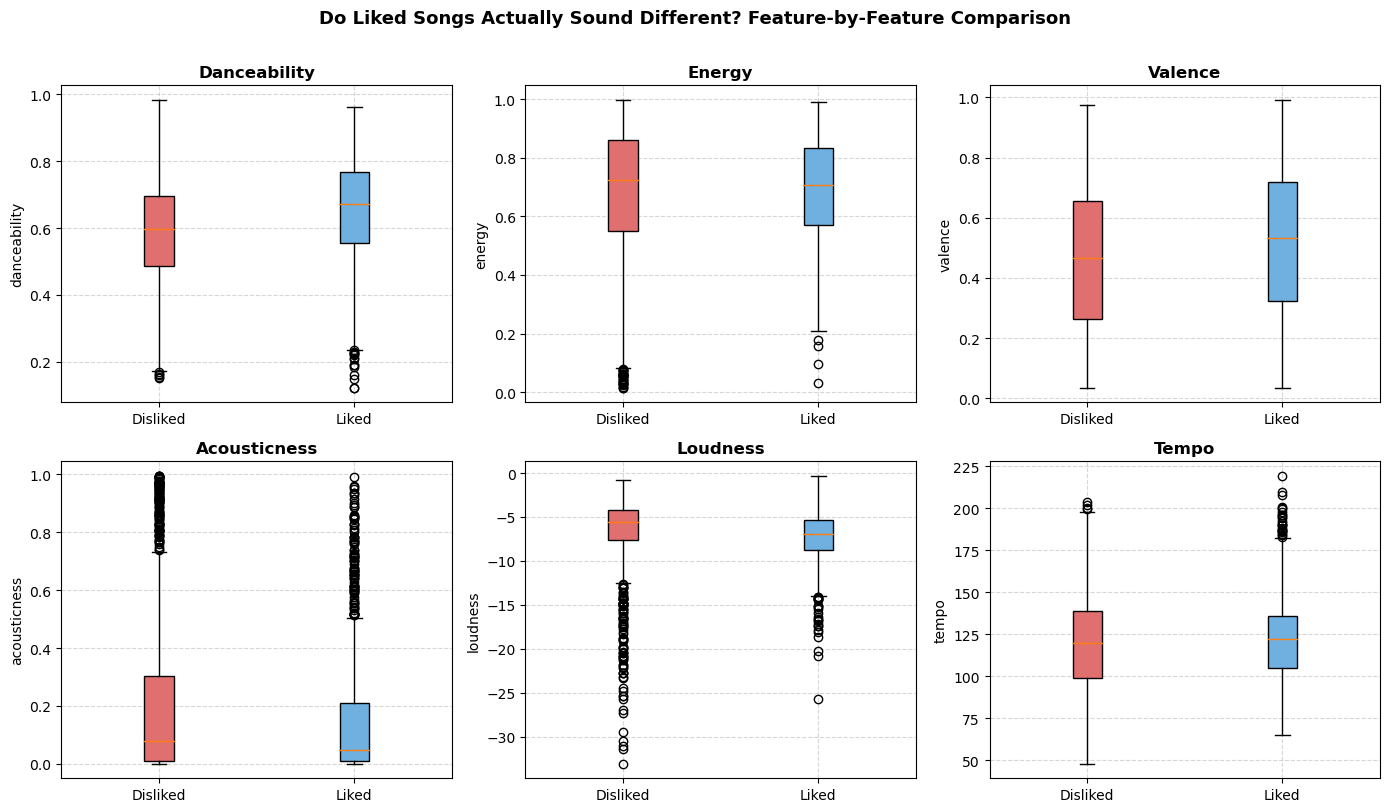

In [8]:
spotify.visualise_feature_boxplots()

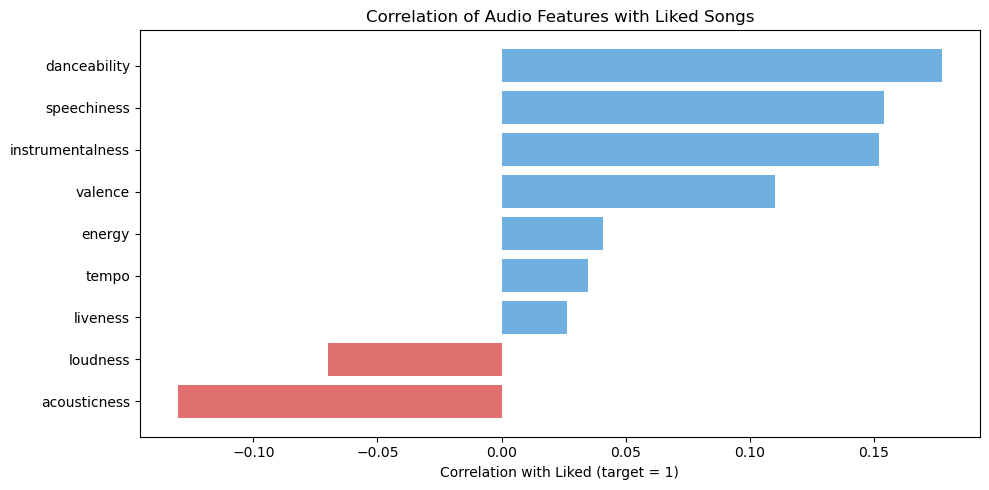

In [9]:
spotify.visualise_correlation_bar()

### RQ2 — Findings

Yes — liked and disliked songs do sound measurably different, though the 
differences are subtle rather than dramatic.

Danceability is the strongest positive differentiator (r = 0.18): liked 
songs have a more consistent, rhythmic beat. Speechiness (r = 0.15) and 
instrumentalness (r = 0.15) also show a positive relationship with being 
liked.

On the opposite side, acousticness is the strongest negative predictor 
(r = -0.13) and loudness also shows a negative relationship (r = -0.07): 
songs that sound organic or quieter are more likely to be disliked. The 
picture that emerges is of a listener who prefers produced, beat-driven 
music over acoustic tracks.

The box plots reveal considerable overlap between both groups across every 
feature — confirming that while the average differences are real, no single 
feature cleanly separates liked from disliked songs. This is precisely why 
RQ1 achieved only 65.5% accuracy: taste is encoded across the combination 
of all features, not any one of them alone.

## RQ3 — How many sound dimensions does Spotify actually need to describe a song?

Spotify uses 9 audio features to describe every track. But are all 9 
genuinely measuring different things — or are some of them redundant?

We use Principal Component Analysis (PCA) to answer this. PCA finds the 
minimum number of summary axes needed to capture most of the variation 
across all 9 features. If just 2 components were enough, the features 
would mostly be measuring the same thing. If many are needed, each 
feature is capturing something genuinely unique.

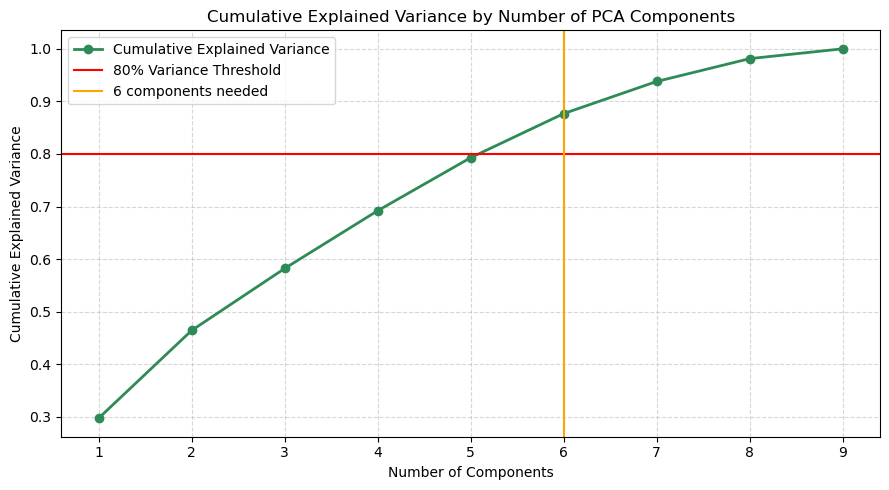

Components needed to capture 80% of variance: 6
This means 6 out of 9 features capture most of what makes songs sound different.


In [10]:
# Apply PCA — this generates the cumulative variance plot automatically
spotify.apply_pca(target_variance=0.80)

### RQ3 — Findings

The cumulative variance plot shows that **6 components are needed to capture 80% 
of the variation** across Spotify's 9 audio features. This means the features are 
not redundant — each one is measuring a genuinely distinct aspect of how a song sounds.

In practical terms: you cannot summarise a song's sonic identity with just one or 
two numbers. Mood, energy, acousticness, and rhythm all contribute independently to 
what makes a track sound the way it does. This also explains why the classifier in 
RQ1 achieved moderate accuracy — the complexity of the feature space means taste 
cannot be reduced to a simple pattern.

## RQ4 — Do songs naturally fall into sound profiles — and does one get liked more?

Even without knowing whether a song is liked or disliked, do songs 
naturally group into distinct sonic categories based on their audio 
features alone? And if so, does the listener consistently prefer one 
type over another?

We use K-Means clustering to group all 2,012 songs by their audio 
features, then check what percentage of each cluster was liked. The 
algorithm has no knowledge of liked/disliked when forming the groups — 
it clusters purely by sonic similarity.

Silhouette Score (k=4): 0.1415
(Score closer to 1.0 means clusters are well separated)
Like Rate per Cluster
 Cluster  Like Rate
       0      0.585
       1      0.441
       2      0.532
       3      0.324


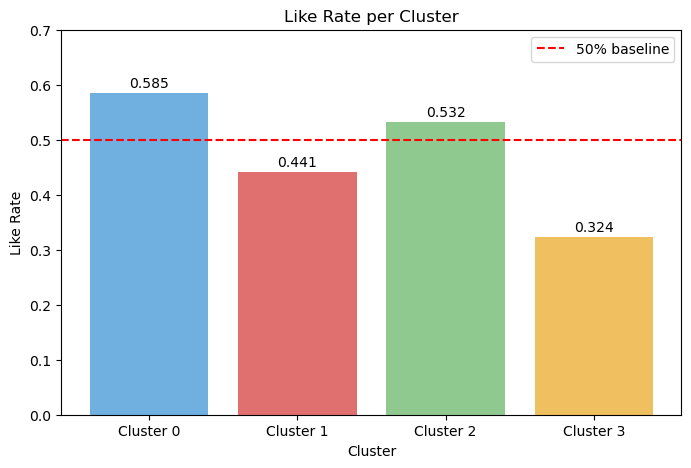

In [11]:
spotify.cluster_songs(n_clusters=4)

### RQ4 — Findings

K-Means grouped all songs into 4 clusters based purely on their audio 
features, with a silhouette score of 0.14. This low score tells us that 
songs do not form sharply distinct natural groups — music exists on a 
continuous sonic spectrum rather than falling into clearly separated 
categories.

Despite this, the like rates differ meaningfully across clusters:
- Cluster 0: 58.5% liked (most preferred)
- Cluster 2: 53.2% liked
- Cluster 1: 44.1% liked
- Cluster 3: 32.4% liked (least preferred)

Looking at the average feature profile per cluster, Cluster 0 — the most 
liked — scores highest on danceability (0.732) and valence (0.680), while 
Cluster 3 — the least liked — scores highest on acousticness (0.795) and 
lowest on energy (0.243). This is entirely consistent with RQ2's finding 
that danceability predicts liking and acousticness predicts disliking, but 
now confirmed through an unsupervised method that had no knowledge of 
taste when forming the groups.
